In [1]:
import pandas as pd
from pathlib import Path
from neural_priors.utils.data import Subject, get_all_subject_ids
from neural_priors.encoding_model2.decode import get_decoding_paradigm
import numpy as np
from tqdm.notebook import tqdm
from tqdm.contrib.itertools import product
import pingouin as pg
import seaborn as sns
import matplotlib.pyplot as plt

bids_folder = Path('/data/ds-neuralpriors')



subject = '02'


def get_pdf(subject, smoothed=False, model_label=4, fit_responses=False, n_voxels=100):
    # Load subject
    sub = Subject(subject, bids_folder=bids_folder)

    # Create target folder
    key = f'model{model_label}'

    if smoothed:
        key += '.smoothed'

    if fit_responses:
        key += '.fit_responses'

    target_dir = bids_folder / 'derivatives' / 'decoding2' / key / f'sub-{subject}' / 'func'

    # sub-04_mask-NPCr_nvoxels-100_pars.tsv
    pdf = pd.read_csv(target_dir / f'sub-{subject}_mask-NPCr_nvoxels-{n_voxels}_pars.tsv', sep='\t', index_col=[0,1], header=[0,1], )
    paradigm = get_decoding_paradigm(sub, fit_responses=fit_responses, drop_levels=False)
    pdf.index = paradigm.index

    pdf.set_index(paradigm['x'], append=True, inplace=True)
    pdf.set_index(paradigm['range'], append=True, inplace=True)

    pdf.columns.names = ['n', 'range']

    # Make first level of columns float 32
    new_columns = pd.MultiIndex.from_arrays([pdf.columns.get_level_values(0).astype(np.float32), pdf.columns.get_level_values(1)], names=pdf.columns.names)

    # Assign the new MultiIndex back to the DataFrame
    pdf.columns = new_columns

    return pdf

def summarize_pdf(pdf):
    pdf0 = pdf.xs('0.0', level=1, axis=1)
    
    pdf0 /= np.trapz(pdf0, pdf0.columns.astype(np.float32), axis=1)[:, np.newaxis]
    E0 = np.trapz(pdf0 * pdf0.columns.values.astype(float)[np.newaxis, :], pdf0.columns.astype(np.float32), axis=1)

    sd0 = np.trapz(np.abs(E0[:, np.newaxis] - pdf0.columns.values.astype(float)[np.newaxis, :]) * pdf0, pdf0.columns.astype(np.float32), axis=1)

    pdf1 = pdf.xs('1.0', level=1, axis=1)
    pdf1 /= np.trapz(pdf1, pdf1.columns.astype(np.float32), axis=1)[:, np.newaxis]
    E1 = np.trapz(pdf1 * pdf1.columns.values.astype(float)[np.newaxis, :], pdf1.columns.astype(np.float32), axis=1)
    sd1 = np.trapz(np.abs(E1[:, np.newaxis] - pdf1.columns.values.astype(float)[np.newaxis, :]) * pdf1, pdf1.columns.astype(np.float32), axis=1)

    ix_ = pd.IndexSlice

    pdf0_ = pdf0.loc[:, :25]
    pdf0_ /= np.trapz(pdf0_, pdf0_.columns.astype(np.float32), axis=1)[:, np.newaxis]

    E20 = np.trapz(pdf0_ * pdf0_.columns.values.astype(float)[np.newaxis, :], pdf0_.columns.astype(np.float32), axis=1)
    E21 = E1

    E = np.where(pdf.index.get_level_values('range') == 0.0, E0, E1)
    E2 = np.where(pdf.index.get_level_values('range') == 0.0, E20, E21)
    sd = np.where(pdf.index.get_level_values('range') == 0.0, sd0, sd1)

    E_swapped = np.where(pdf.index.get_level_values('range') == 0.0, E1, E0)

    pars = pd.DataFrame(index=pdf.index, columns=['E', 'sd'])
    pars['E'] = E
    pars['E2'] = E2
    pars['sd'] = sd
    pars['E_swapped'] = E_swapped

    pars.reset_index(['x', 'range'], inplace=True)

    pars['error'] = pars['E'] - pars['x']
    pars['abs(error)'] = np.abs(pars['error'])


    return pars

In [2]:
subjects = get_all_subject_ids()

smootheds = [False]

model_labels = [3, 4, 5]
n_voxels_ = [0,]

pdfs = []
keys = []
pars = []

for subject, smoothed, model_label, fit_responses, n_voxels in product(subjects, smootheds, model_labels, [False], n_voxels_):
    try:
        pdf = get_pdf(subject, smoothed=smoothed, model_label=model_label, fit_responses=fit_responses, n_voxels=n_voxels)
        pars_ = summarize_pdf(pdf)
        pdfs.append(pdf)
        keys.append((subject, smoothed, model_label, fit_responses, n_voxels))
        pars.append(pars_.droplevel('subject'))
    except FileNotFoundError:
        print(f'File not found for subject {subject}, smoothed={smoothed}, model_label={model_label}, fit_responses={fit_responses}, n_voxels={n_voxels}')
        continue
    except Exception as e:
        print(f'Error for subject {subject}, smoothed={smoothed}, model_label={model_label}, fit: {e}, {fit_responses}, (n_voxels={n_voxels})')
        continue

pdf = pd.concat(pdfs, keys=keys, names=['subject', 'smoothed', 'model_label', 'fit_responses', 'n_voxels'])
pars = pd.concat(pars, keys=keys, names=['subject', 'smoothed', 'model_label', 'fit_responses', 'n_voxels'])

# Make subject index integers
pars = pars.reset_index('subject').droplevel(['smoothed', 'fit_responses', 'n_voxels', 'run2'])
pars['subject'] = pars['subject'].astype(int)
pars.set_index('subject', inplace=True, append=True)
pars = pars.reorder_levels(['model_label', 'subject', 'session', 'run', 'trial_nr'])


pars['range'] = pars['range'].map({0.0:'Narrow', 1.0:'Wide'})

  0%|          | 0/117 [00:00<?, ?it/s]

In [3]:
cog_pars = pd.read_csv('/data/ds-neuralpriors/derivatives/behavioral_modeling/behmodel_3b_pars.csv', index_col=0)

cog_pars['log(nu_n)'] = np.log(cog_pars['nu_n'])

x   range          E        sd  \
model_label subject session run trial_nr                                      
3           1       1       1   1         11.0  Narrow  33.626807  3.920618   
                                2         23.0  Narrow  30.557741  4.833797   
                                3         23.0  Narrow  34.770495  3.241375   
                                4         22.0  Narrow  19.962107  5.625331   
                                5         21.0  Narrow  21.961769  3.708019   
...                                        ...     ...        ...       ...   
5           41      2       8   26        24.0  Narrow  31.652157  4.248175   
                                27        19.0  Narrow  30.388450  5.060827   
                                28        17.0  Narrow  22.938741  5.381013   
                                29        19.0  Narrow  14.237033  2.302720   
                                30        19.0  Narrow  20.184651  7.204514   

                                                 E2  E_swapped      error  \
model_label subject session run trial_nr                                    
3           1       1       1   1         22.805322  36.155089  22.626807   
                                2         17.197860  31.246879   7.557741   
                                3         22.759561  35.856504  11.770495   
                                4         16.886405  18.239922  -2.037893   
                                5         19.975613  28.393417   0.961769   
...                                             ...        ...        ...   
5           41      2       8   26        20.947504  33.360225   7.652157   
                                27        18.563060  20.158702  11.388450   
                                28        18.704277  24.353868   5.938741   
                                29        14.063235  28.330979  -4.762967   
                                30        15.298099  29.684066   1.184651   

                                          abs(error)  
model_label subject session run trial_nr              
3           1       1       1   1          22.626807  
                                2           7.557741  
                                3          11.770495  
                                4           2.037893  
                                5           0.961769  
...                                              ...  
5           41      2       8   26          7.652157  
                                27         11.388450  
                                28          5.938741  
                                29          4.762967  
                                30          1.184651  

[56160 rows x 8 columns]

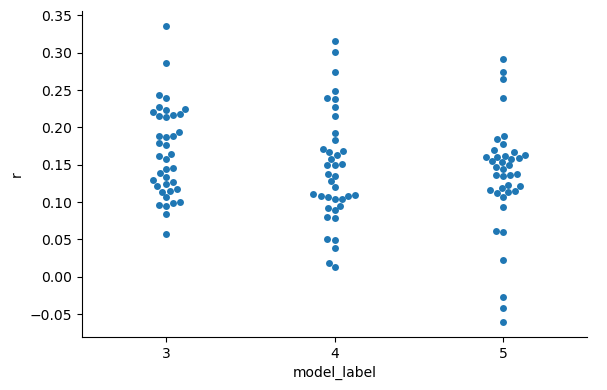

<Figure size 640x480 with 0 Axes>

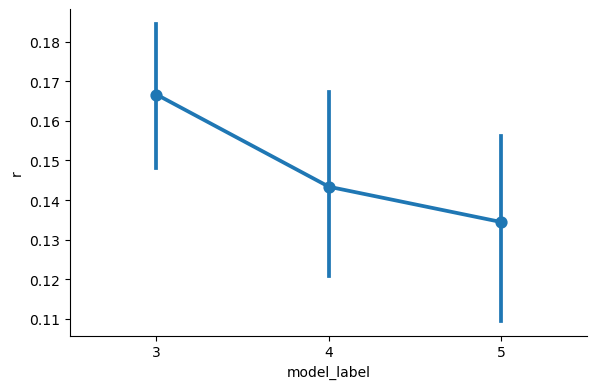

In [8]:
r = pars.groupby(['model_label', 'subject']).apply(lambda d: pg.corr(d['E'], d['x']))


sns.catplot(data=r, y='r', x='model_label', kind='swarm', height=4, aspect=1.5)

plt.figure()
sns.catplot(data=r, y='r', x='model_label', kind='point', height=4, aspect=1.5)

/var/folders/d4/cpqhwlbn301clph1qk64k01nmjkty3/T/ipykernel_586/2958297420.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  r = pars.groupby(['model_label', 'subject', 'range']).apply(lambda d: pg.corr(d['E'], d['x']))


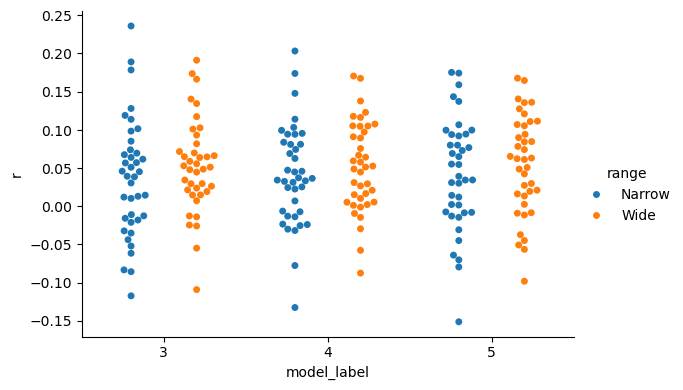

<Figure size 640x480 with 0 Axes>

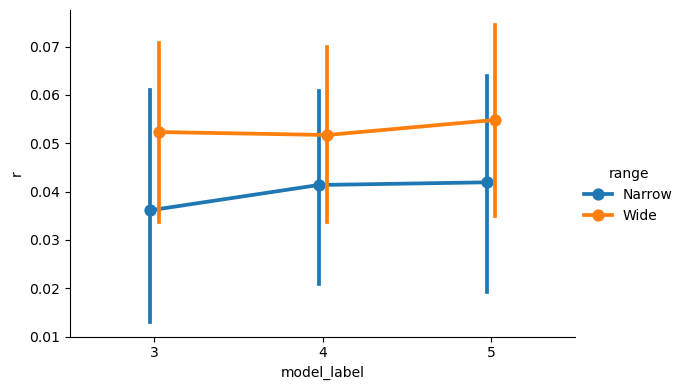

In [11]:
r = pars.groupby(['model_label', 'subject', 'range']).apply(lambda d: pg.corr(d['E'], d['x']))


sns.catplot(data=r, y='r', x='model_label', kind='swarm', height=4, aspect=1.5, hue='range', dodge=True)

plt.figure()
sns.catplot(data=r, y='r', x='model_label', kind='point', height=4, aspect=1.5, hue='range', dodge=True)

,,n,r,CI95%,p-val,BF10,power
model_label,,,,,,,
3,pearson,39,0.263449,"[-0.06, 0.53]",0.105129,0.708,0.373228
4,pearson,39,0.080513,"[-0.24, 0.39]",0.626092,0.224,0.077453
5,pearson,39,0.323840,"[0.01, 0.58]",0.044311,1.402,0.531020


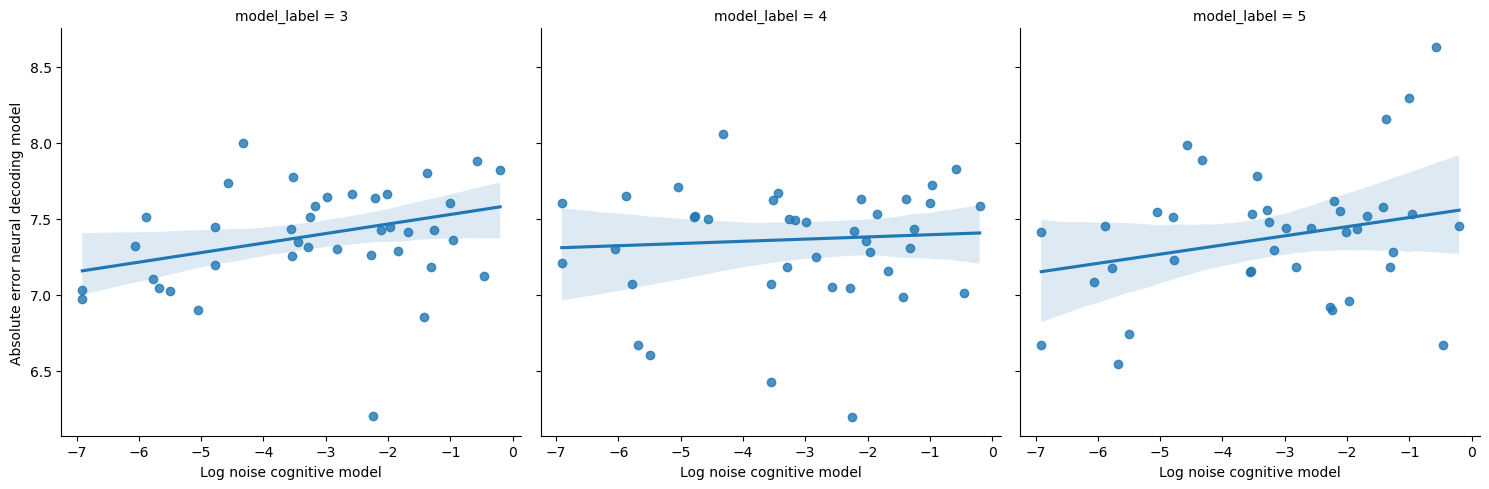

In [5]:
tmp = pars.groupby(['model_label', 'subject'])[['abs(error)']].mean().join(cog_pars)

g = sns.lmplot(y='abs(error)', x='log(nu_n)', data=tmp.reset_index(), robust=True, col='model_label')

g.set_xlabels('Log noise cognitive model')
g.set_ylabels('Absolute error neural decoding model')


# pg.corr(x=tmp['log(nu_n)'], y=tmp['abs(error)'], method='pearson',)

tmp.groupby(['model_label']).apply(lambda d: pg.corr(d['log(nu_n)'], d['abs(error)'], method='pearson',))

,,n,r,CI95%,p-val,BF10,power
model_label,,,,,,,
3,pearson,39,-0.259311,"[-0.53, 0.06]",0.110911,0.679,0.363078
4,pearson,39,-0.134164,"[-0.43, 0.19]",0.415482,0.275,0.129218
5,pearson,39,-0.336300,"[-0.59, -0.02]",0.036326,1.65,0.564621


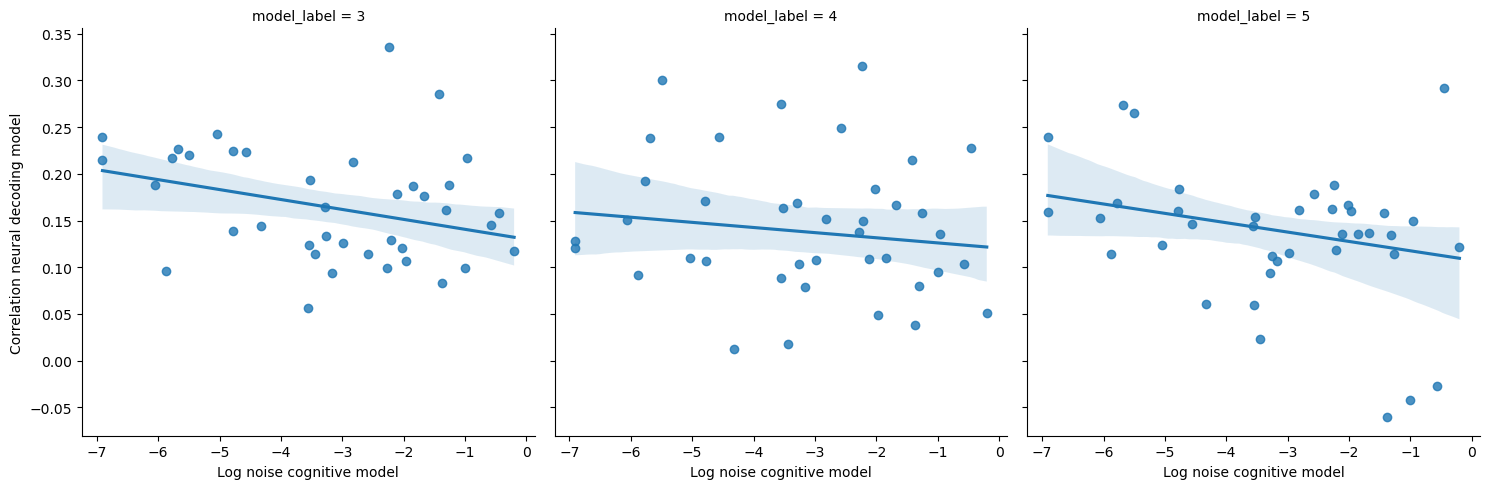

In [7]:
tmp = r.groupby(['model_label', 'subject'])[['r']].mean().join(cog_pars)

g = sns.lmplot(y='r', x='log(nu_n)', data=tmp.reset_index(), robust=True, col='model_label')

g.set_xlabels('Log noise cognitive model')
g.set_ylabels('Correlation neural decoding model')


# pg.corr(x=tmp['log(nu_n)'], y=tmp['abs(error)'], method='pearson',)

tmp.groupby(['model_label']).apply(lambda d: pg.corr(d['log(nu_n)'], d['r'], method='pearson',))

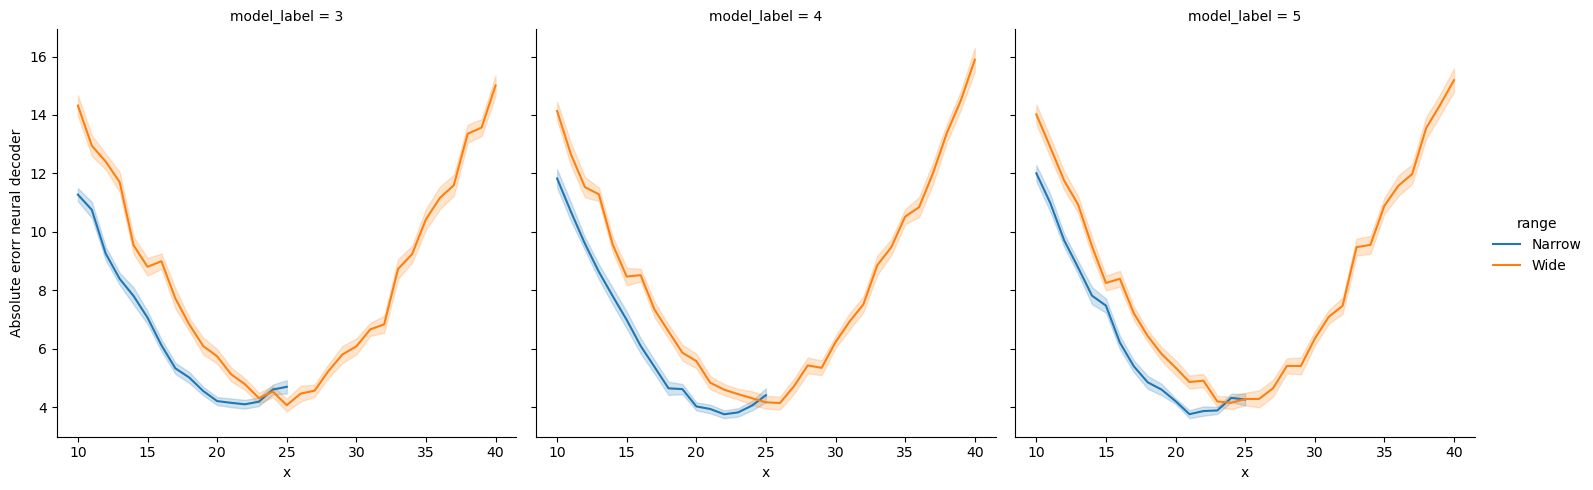

In [106]:
sd = pars.groupby(['model_label', 'subject', 'x', 'range'])[['abs(error)']].mean(0)


g = sns.relplot(
    data=sd.reset_index(),
    x='x',
    y='abs(error)',
    hue='range',
    kind='line',
    col='model_label',
    errorbar='se'
)

g.set_ylabels('Absolute erorr neural decoder')

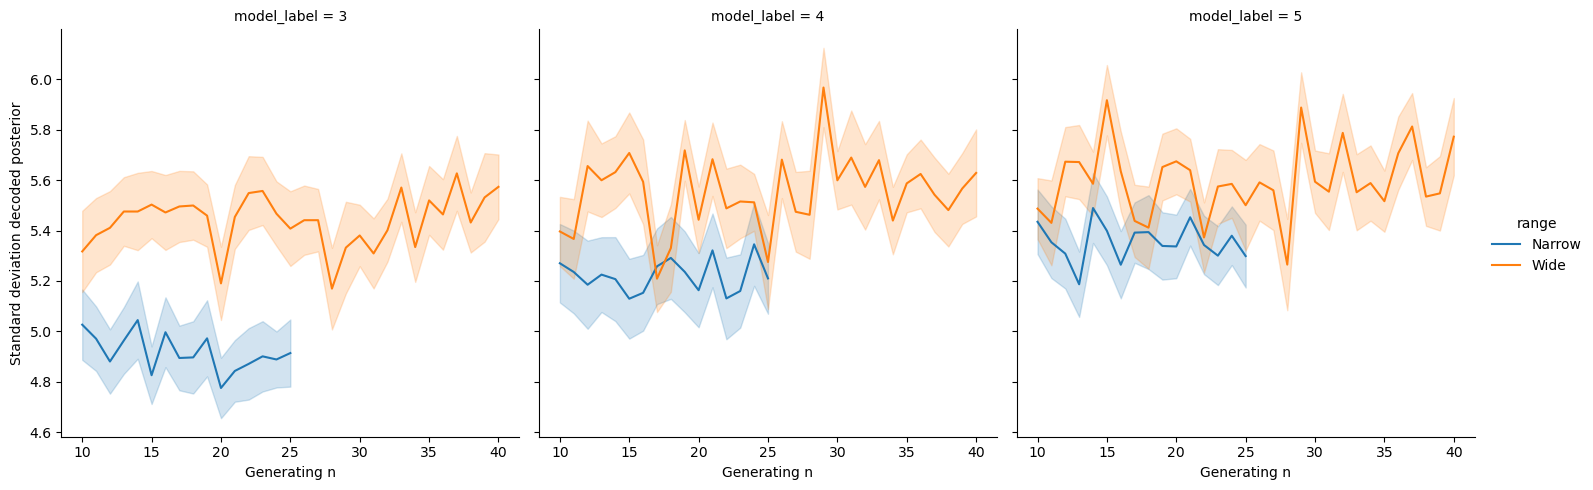

In [107]:
sd = pars.groupby(['model_label', 'subject', 'x', 'range'])[['sd']].mean(0)

g = sns.relplot(
    data=sd.reset_index(),
    x='x',
    y='sd',
    hue='range',
    kind='line',
    col='model_label',
    errorbar='se'
)


g.set_ylabels('Standard deviation decoded posterior')
g.set_xlabels('Generating n')

<Axes: xlabel='log_ratio', ylabel='sd_diff'>

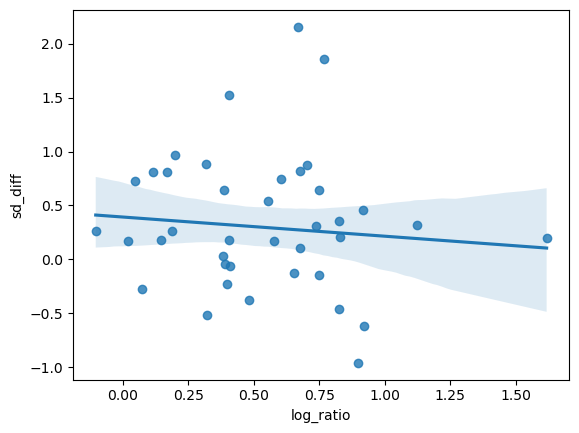

In [109]:
sd = pars[pars['x'] < 26].groupby(['subject', 'range'])[['sd']].mean().unstack()['sd']


sd_diff = sd['Wide'] - sd['Narrow']

cog_pars['log_ratio'] = np.log(cog_pars['ratio'])
sd_diff.to_frame('sd_diff').join(cog_pars)

sns.regplot(
    y='sd_diff',
    x='log_ratio',
    data=sd_diff.to_frame('sd_diff').join(cog_pars),
    robust=True,
)

<Axes: xlabel='log_ratio', ylabel='sd_diff'>

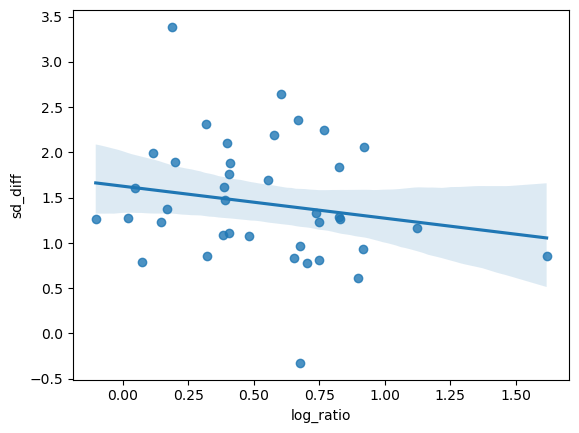

In [111]:
sd = pars[pars['x'] < 26].groupby(['subject', 'range'])[['abs(error)']].mean().unstack().droplevel(0, axis=1)


sd_diff = sd['Wide'] - sd['Narrow']

cog_pars['log_ratio'] = np.log(cog_pars['ratio'])
sd_diff.to_frame('sd_diff').join(cog_pars)

sns.regplot(
    y='sd_diff',
    x='log_ratio',
    data=sd_diff.to_frame('sd_diff').join(cog_pars),
    robust=True,
)